deletes multicollinearity

# Cell 1: Import libraries


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, RepeatedKFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

# Cell 2: Load the data


In [2]:
url = 'https://raw.githubusercontent.com/amyaby/Machine-learning/refs/heads/main/datasets/housing.csv'
df = pd.read_csv(url)

# Cell 3: View first few rows


In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200


# Cell 4: Check data info


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5)
memory usage: 1.4 MB


# Cell 5: Separate features and target


In [5]:
X = df.drop(['median_house_value'], axis=1)
y = df['median_house_value']

# Cell 6: Split into train and test sets


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Cell 7: Handle missing values with SimpleImputer


In [7]:
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Cell 8: Train Ridge model


In [8]:
Ridge_model = Ridge(alpha=1).fit(X_train, y_train)

# Cell 9: Check intercept


In [9]:
Ridge_model.intercept_

np.float64(-3590685.8479978577)

# Cell 10: Make predictions


In [10]:
y_pred = Ridge_model.predict(X_test)

## RIDGE REGRESSION
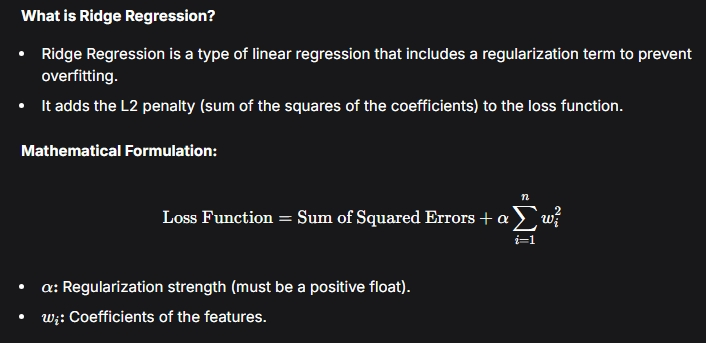

`Advantages:`

-> Reduces the complexity of the model by shrinking coefficients.  
-> Helps in handling multicollinearity.


# Cell 11: Calculate RMSE

In [11]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(70276.05667297242)

# Cell 12: Calculate R² Score


In [ ]:
r2_score(y_test, y_pred)

0.6267641650937725

: 